In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from tqdm import tqdm
from sklearn.model_selection import KFold

In [2]:
data = pd.read_csv("all_features_raw.csv")

In [3]:
data = data[~data['type'].astype(str).str.contains(r'checkpoints|\.', na=False, regex=True)]

In [4]:
#Creating the dependent variable class
factor = pd.factorize(data['type'])
data.type = factor[0]
definitions = factor[1]
print(data.type.head())
print(definitions)

0    0
1    0
2    0
3    0
4    0
Name: type, dtype: int64
Index(['EC', 'L', 'EB', 'RRAB_BL', 'EA', 'RRAB', 'DCEP-FU', 'ROT', 'CEP', 'E',
       'DSCT', 'ED', 'RS', 'DCEPS', 'RRC', 'SR', 'RR', 'ACV', 'RRD', 'HADS',
       'DCEP', 'EW'],
      dtype='str')


In [5]:
#split the dataset into independent and dependent variables
X = data.drop('type', axis=1).values
y = data['type'].values

In [6]:
folds = 10
k_fold = KFold(n_splits=folds, shuffle=True, random_state=1)

predicted_targets = np.array([])
actual_targets = np.array([])

for train_ix, test_ix in tqdm(k_fold.split(X), total=folds, desc="Validación cruzada"):
    train_x, train_y = X[train_ix], y[train_ix]
    test_x, test_y = X[test_ix], y[test_ix]

    # Escalado (opcional para Random Forest)
    scaler = StandardScaler()
    train_x = scaler.fit_transform(train_x)
    test_x = scaler.transform(test_x)

    classifier = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
    classifier.fit(train_x, train_y)

    predicted_labels = classifier.predict(test_x)

    predicted_targets = np.append(predicted_targets, predicted_labels)
    actual_targets = np.append(actual_targets, test_y)

# Forzar todas las clases (0 .. len(definitions)-1) en la matriz de confusión
all_classes = np.arange(len(definitions))
cnf_matrix = confusion_matrix(actual_targets, predicted_targets, labels=all_classes)

Validación cruzada: 100%|███████████████████████████████████████████| 10/10 [01:03<00:00,  6.32s/it]


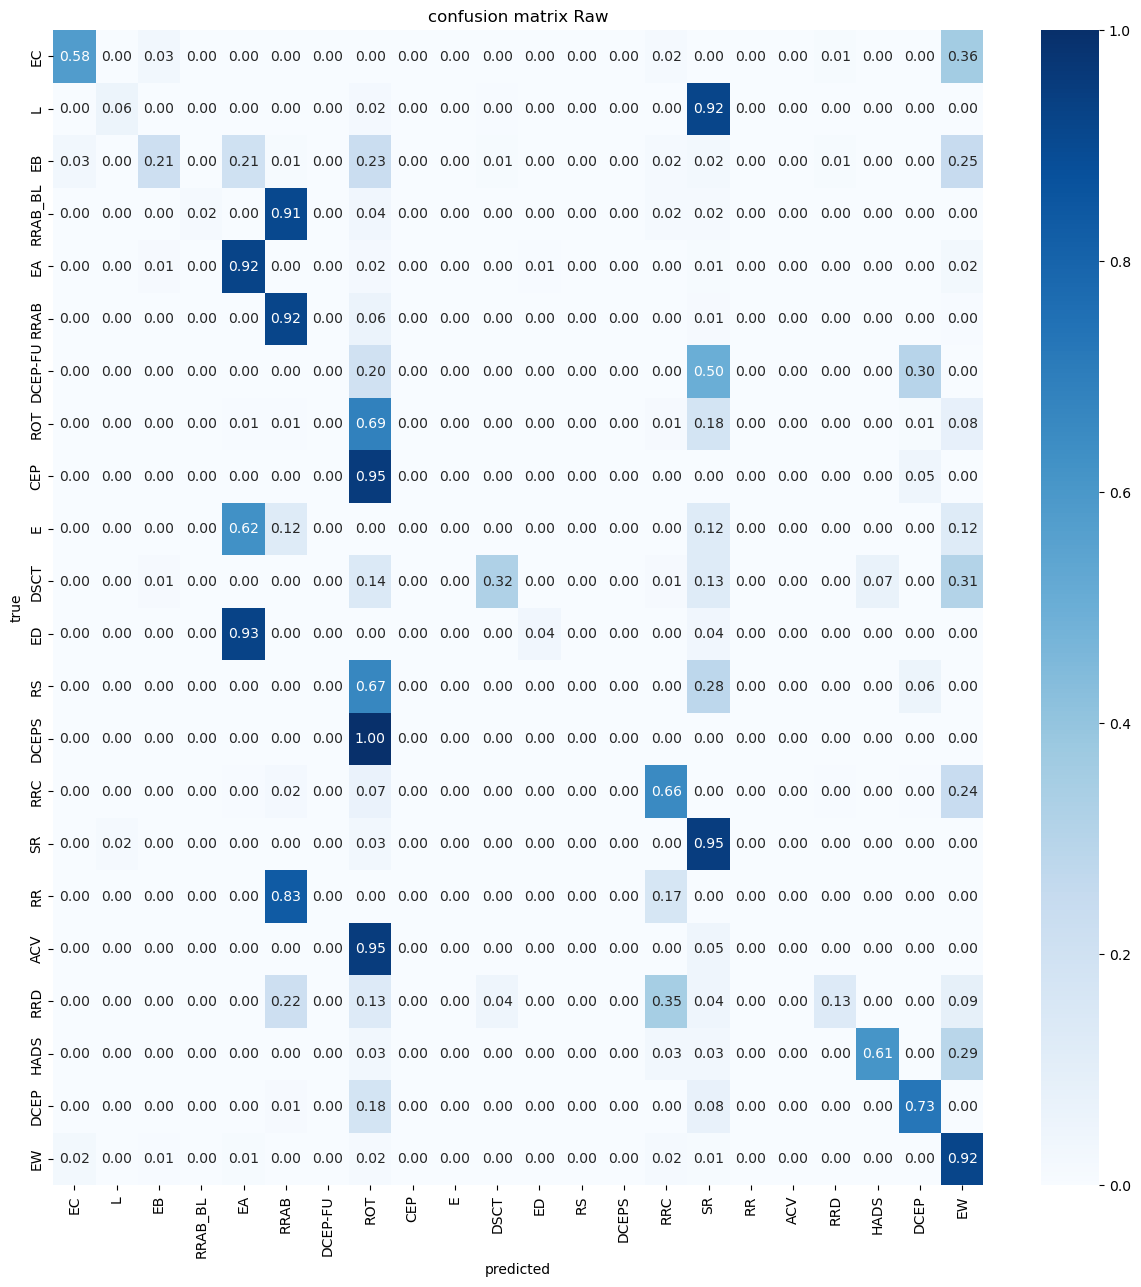

In [7]:


def to_density(cf):
  '''
  This function will take in a confusion matrix cf and return the relative 'density' of every element in each row.
  ---------
  cf: Confusion matrix to be passed in
  '''
  density = []
  n, k = cf.shape
  for i in range(n):
    density_row = []
    for j in range(k):
      total_stars = sum(cf[i])
      density_row.append(cf[i][j]/total_stars)
    density.append(density_row)
  return np.array(density)


def make_confusion_matrix(cf_,
                          xlabel, ylabel,
                          group_names=None,
                          categories_x='auto',
                          categories_y='auto',
                          count=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None,
                          ):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    ---------
    cf_:            Confusion matrix to be passed in
    group_names:   List of strings that represent the labels row by row to be shown in each square.
    categories:    List of strings containing the categories to be displayed on the x,y axis. Default is 'auto'
    count:         If True, show the raw number in the confusion matrix. Default is True.
    cbar:          If True, show the color bar. The cbar values are based off the values in the confusion matrix.
                   Default is True.
    xyticks:       If True, show x and y ticks. Default is True.
    xyplotlabels:  If True, show 'True Label' and 'Predicted Label' on the figure. Default is True.
    sum_stats:     If True, display summary statistics below the figure. Default is True.
    figsize:       Tuple representing the figure size. Default will be the matplotlib rcParams value.
    cmap:          Colormap of the values displayed from matplotlib.pyplot.cm. Default is 'Blues'
                   See http://matplotlib.org/examples/color/colormaps_reference.html
                   
    title:         Title for the heatmap. Default is None.
    '''

    cf = to_density(cf_)
    
    # Generate the labels for the matrix elements:
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.2f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    box_labels = [f"{v1}{v2}".strip() for v1, v2 in zip(group_labels,group_counts)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # Set figure paramaters:
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # Make the heatmap:
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,yticklabels=categories_y,xticklabels=categories_x)

    if xyplotlabels:
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        
    if title:
        plt.title(title)
    plt.title("confusion matrix Raw")
    plt.savefig("confusion_matrix_raw.png", dpi =600)
        

# Make a confusion matrix plot for 10-fold cross-validation:

make_confusion_matrix(cnf_matrix, xlabel='predicted', ylabel='true',categories_x=definitions,categories_y=definitions, count=True, figsize=(15,15))

/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ruben/miniconda3/envs/astro/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

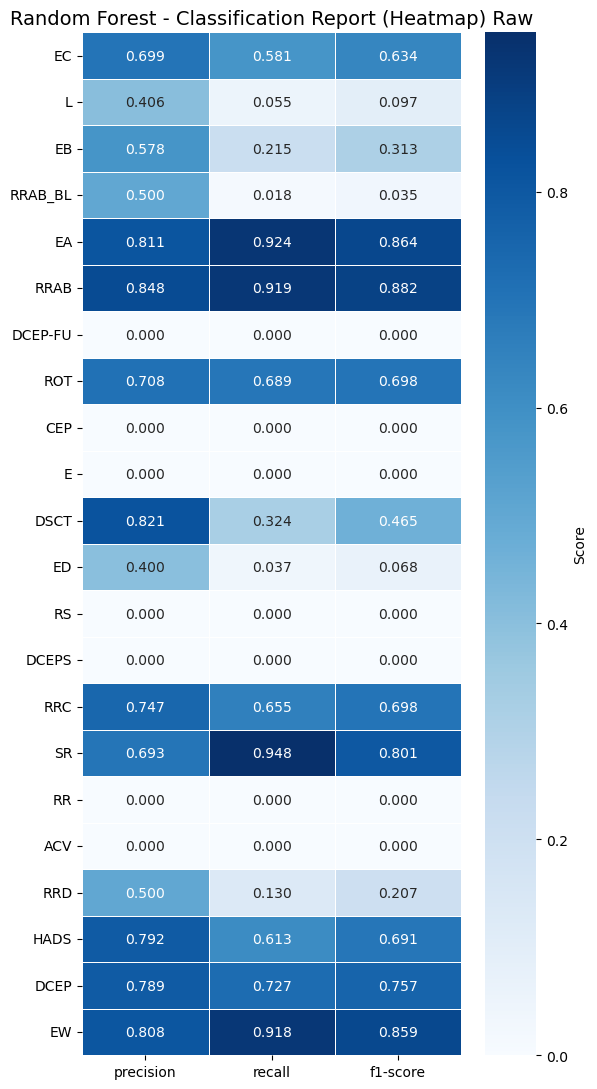

In [8]:

def heatmap_classification_report(y_true, y_pred, class_names=None, 
                                  title="Classification Report Meidan after Detrended", 
                                  save_path="classification_report_heatmap_median after.png"):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df = pd.DataFrame(report).transpose()
    
    # Separar las filas de clases y los promedios (si quieres solo clases)
    # Aquí tomamos solo las filas que corresponden a clases (que tienen 'support' y no son 'accuracy')
    classes_df = df[~df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    classes_df = classes_df.drop(columns=['support'])  # opcional: eliminar support para heatmap
    
    plt.figure(figsize=(max(6, len(classes_df.columns)*1.2), max(4, len(classes_df)*0.5)))
    sns.heatmap(classes_df, annot=True, fmt='.3f', cmap='Blues', 
                linewidths=0.5, cbar_kws={'label': 'Score'})
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
heatmap_classification_report(actual_targets, predicted_targets,
                              class_names=definitions,
                              title="Random Forest - Classification Report (Heatmap) Raw",
                              save_path="classification_report_heatmap_raw.png")